# Constructive validity - MAE
## Cerebellar MF (hybrid TVB) vs Reduced Wong-Wang, single subject, 27 cerebellar regions

Same pipeline used in cMF-TVB - prototype of hybrid virtual brain:

- removal of the first `vol_tr` = 5 volumes from both simulated and empirical BOLD;
- empirical BOLD truncated to the simulated length, DCN removed, cerebellar cortex isolated (`[:, 93:]`);
- MAE computed with `compute_mae` from `constr_validity_comp_scores`.

**Note**
The simulation used here has connectivity parameters tuned on an *engineering SC* to account for parallel fibers connectivity. This version of the connectome will be replaced by the curated connectome (ongoing works for forebrain (Huifang Wang & Nan Huang) and for hindbrain (Marta Gaviraghi & Eleonora Lupi)

In [1]:
try:
    import tvb.simulator.lab
    print('tvb-library already installed')
except ImportError:
    print('installing tvb-library ...')
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'tvb-library'], check=True)
    print('>>> If Colab asks to restart the runtime: restart and re-run this cell.')

try:
    import numba
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'numba'], check=True)

# ----------------------------------------------------------------------------
# Mount Google Drive -----------------------------------------------------
# ----------------------------------------------------------------------------
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print('Not running in Colab: skipping Drive mount BUT CHECK THE PATHS')


import os
import json
import time

import numpy as np
import numpy.random as rgn
import matplotlib.pyplot as plt
import numpy as np

import zipfile

day_folder = '/content/drive/MyDrive/EITN_school_2026_MFM/Day5'
os.chdir(day_folder)

# Ad-hoc developed function
from utils.constr_validity_plot_funct import *
from utils.constr_validity_comp_scores import *

%matplotlib inline

/usr/local/lib/python3.13/dist-packages/tvb/datatypes/surfaces.py:60: UserWarning: Geodesic distance module is unavailable; some functionality for surfaces will be unavailable.
  warnings.warn(msg)


tvb-library already installed
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:

# # SIMULATED BOLD FILES (outputs of the two simulation notebooks) ----------------------------------------
sim_file_mf = os.path.join('cerebellum_zmin.npz')  # cerebellar MF (hybrid TVB)
sim_file_ww = os.path.join('cerebellum_WW.npz')    # Reduced Wong-Wang

# # EMPIRICAL BOLD -----------------------------------------------------------------------------------------
emp_name = os.path.join(day_folder,'ROISignals_ROISignals.txt')

# # FIXED PARAMETERS (as in constr_validity_pipeline.py) ----------------------------------------------------
vol_tr = 5                                   # BOLD volumes removed (simulated AND empirical)
DCN_idx = [103, 104, 105, 113, 114, 115]     # deep cerebellar nuclei in the empirical parcellation
TR = 0.720                                   # repetition time [s]


### Load simulated BOLD

In [3]:
def load_sim_bold(npz_file):
    """Load BOLD data/time from the .npz saved by the simulation notebooks.
    Returns bold (time x regions), time [s] and the metadata."""
    d = np.load(npz_file)
    bold = np.asarray(d['bold_data'])
    # TVB monitor shape can be (time, voi, nodes, modes): keep first variable of interest and first mode,
    # as in the pipeline (simBOLD_ww[:, 0, :])
    if bold.ndim == 4:
        bold = bold[:, 0, :, 0]
    elif bold.ndim == 3:
        bold = bold[:, 0, :]
    bold_time = np.asarray(d['bold_time']).squeeze() * 1e-3   # ms -> s
    meta = {k: d[k].item() if d[k].ndim == 0 else d[k] for k in ['dt', 'TR', 'cond_speed', 'conn_name'] if k in d.files}
    return bold, bold_time, meta

simBOLD, simBOLD_time, meta_mf = load_sim_bold(sim_file_mf)
simBOLD_ww, simBOLD_time_ww, meta_ww = load_sim_bold(sim_file_ww)

print('MF : ', np.shape(simBOLD), meta_mf)
print('WW : ', np.shape(simBOLD_ww), meta_ww)

MF :  (166, 27) {'dt': 0.5, 'TR': 720, 'cond_speed': 3.0, 'conn_name': 'curatedSC'}
WW :  (166, 27) {'dt': 0.5, 'TR': 720.0, 'cond_speed': 3.0, 'conn_name': 'SC_dirCB_ONLYCRBL.zip'}


### Region labels (from the SC used in the simulations)

### Simulated BOLD post-processing

In [5]:
# # Removing transient due to computational integration
simBOLD, simBOLD_ww = simBOLD[vol_tr:, :], simBOLD_ww[vol_tr:, :]
simBOLD_time, simBOLD_time_ww = simBOLD_time[vol_tr:], simBOLD_time_ww[vol_tr:]

print('MF: ', simBOLD.shape, ' WW: ', simBOLD_ww.shape)

MF:  (161, 27)  WW:  (161, 27)


### Empirical BOLD

In [6]:
empBOLD_wb = np.loadtxt(emp_name)

# # Removing the first vol_tr volumes, then truncation to the simulated length
empBOLD_tok = empBOLD_wb[vol_tr:, :][:np.shape(simBOLD)[0], :]

# # Removing Deep Cerebellar Nuclei
mask = np.ones(np.shape(empBOLD_tok)[1], dtype=bool)
mask[DCN_idx] = False
empBOLD = empBOLD_tok[:, mask]

# # Isolate cerebellar cortex subnetwork
empBOLD = empBOLD[:, 93:]

print('Empirical: ', empBOLD.shape)
assert empBOLD.shape == simBOLD.shape, f'Empirical {empBOLD.shape} vs simulated {simBOLD.shape}'

Empirical:  (161, 27)



Different models give BOLD in different units and offsets and MAE is sensitive to these differences. Here The same transformation is applied to every model to compare them.

**Why MAE?**
- The question is relative: with everything else fixed, does the cerebellar mean field bring the simulated BOLD closer to data than generic neural masses?
- Connectome, hemodynamics and normalisation are the same for all models, and no parameters are tuned. Any difference comes only from the node model.

In [7]:
# # Simulated BOLD
simBOLD = abs(simBOLD)
simBOLD_m = (simBOLD - np.min(simBOLD)) / (np.max(simBOLD) - np.min(simBOLD))

simBOLD_ww = abs(simBOLD_ww)
simBOLD_ww_m = (simBOLD_ww - np.min(simBOLD_ww)) / (np.max(simBOLD_ww) - np.min(simBOLD_ww))

# # Empirical BOLD
empBOLD = abs(empBOLD)
empBOLD_m = (empBOLD - np.min(empBOLD)) / (np.max(empBOLD) - np.min(empBOLD))


# # Subject dimension first, as in the pipeline: (n_subjects, time, regions)
bold_MF = np.array([simBOLD_m])
bold_WW = np.array([simBOLD_ww_m])
bold_EMP = np.array([empBOLD_m])

print('Check simBOLD MF: ', np.shape(bold_MF), np.min(bold_MF), np.max(bold_MF))
print('Check simBOLD WW: ', np.shape(bold_WW), np.min(bold_WW), np.max(bold_WW))
print('Check empBOLD: ', np.shape(bold_EMP), np.min(bold_EMP), np.max(bold_EMP))

Check simBOLD MF:  (1, 161, 27) 0.0 1.0
Check simBOLD WW:  (1, 161, 27) 0.0 1.0
Check empBOLD:  (1, 161, 27) 0.0 1.0


### Mean Absolute Error

In [11]:
mae_mf_all_subjects, mae_ww_all_subjects, \
mae_SD_mf_all_subjects, mae_SD_ww_all_subjects, \
mae_mf_regions_all_subjects, mae_ww_regions_all_subjects, \
mae_mf_regions_avg, mae_ww_regions_avg, mae_mf_regions_SD, mae_ww_regions_SD = compute_mae(['103'], bold_MF, bold_WW, bold_EMP)

print('MAE EMPvsMF: ', mae_mf_all_subjects, ' SD: ', mae_SD_mf_all_subjects)
print('MAE EMPvsWW: ', mae_ww_all_subjects, ' SD: ', mae_SD_ww_all_subjects)

MAE EMPvsMF:  [np.float64(0.3529336651165213)]  SD:  [np.float64(0.19449292425410328)]
MAE EMPvsWW:  [np.float64(0.3844956051333812)]  SD:  [np.float64(0.2586008006414693)]


### Plots

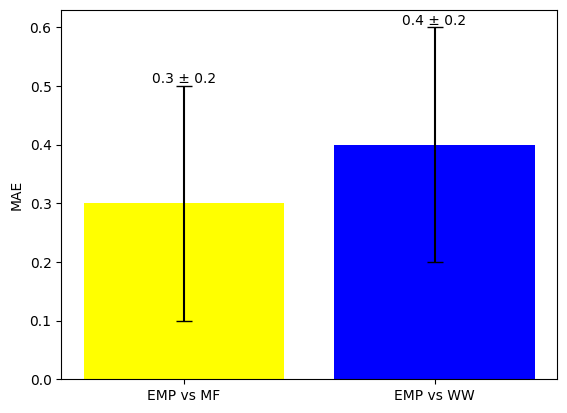

In [18]:
def round1(x):
    t = int(round(float(np.ravel(x)[0]) * 100, 6))
    return (t // 10 + (t % 10 >= 6)) / 10

means = [round1(mae_mf_all_subjects),    round1(mae_ww_all_subjects)]
sds   = [round1(mae_SD_mf_all_subjects), round1(mae_SD_ww_all_subjects)]

plt.bar(['EMP vs MF', 'EMP vs WW'], means, yerr=sds, capsize=6,
        color=['yellow', 'blue'])
for i, (m, s) in enumerate(zip(means, sds)):
    plt.text(i, m + s, f'{m:.1f} ± {s:.1f}', ha='center', va='bottom')
plt.ylabel('MAE')
plt.show()